In [1]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------


import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


import matplotlib.pyplot as plt

In [2]:
# -------------------------------
# 2. LOAD DATASET
# -------------------------------


DATA_PATH = 'Cleaned_Pakistan_Water_Dataset_updated.csv'
df = pd.read_csv(DATA_PATH)


print('Dataset Loaded')
print(df.columns)

Dataset Loaded
Index(['District', 'Year', 'Month', 'Season', 'Crop', 'Soil Type',
       'Soil_Water_Capacity', 'Temperature_C', 'Humidity_Percent',
       'Rainfall_mm', 'Wind_Speed', 'Solar_Radiation', 'Crop_Water_Demand_mm',
       'Water_Balance_mm', 'Water_Shortage_Level', 'Date'],
      dtype='object')


In [3]:
# -------------------------------
# 3. STANDARDIZE COLUMN NAMES
# -------------------------------


df = df.rename(columns={
'Soil Type': 'Soil_Type',
'Crop': 'Crop_Type',
'Rainfall_mm': 'Rainfall'
})

In [4]:
# -------------------------------
# 4. DROP LEAKAGE COLUMNS
# -------------------------------


DROP_COLS = [
'Water_Shortage_Level',
'Water_Balance_mm'
]


df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

In [5]:
# -------------------------------
# 5. SORT & CLEAN
# -------------------------------


df = df.sort_values(by=['District', 'Year', 'Month'])
df = df.dropna().reset_index(drop=True)

In [6]:
# -------------------------------
# 6. ENCODE CATEGORICAL FEATURES
# -------------------------------

label_encoders = {}
for col in ['District', 'Crop_Type', 'Soil_Type', 'Season']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# -------------------------------
# 7. CREATE LAG & SEASONAL FEATURES
# -------------------------------

# Ensure correct sorting
df = df.sort_values(by=['District', 'Year', 'Month'])

# Create rainfall lag
df['Rainfall_lag1'] = df.groupby('District')['Rainfall'].shift(1)

# Create seasonal encoding
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Drop rows with NaNs caused by lag
df = df.dropna().reset_index(drop=True)


In [8]:
# -------------------------------
# 8. FEATURE SET FOR RAINFALL PREDICTION
# -------------------------------


FEATURES = [
'Rainfall_lag1',
'Month_sin', 'Month_cos',
'Year',
'Temperature_C',
'Humidity_Percent',
'Wind_Speed',
'Solar_Radiation'
]


X = df[FEATURES]
y = df['Rainfall']


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, shuffle=False
)

In [9]:
# -------------------------------
# 9. Baseline Model
# -------------------------------

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_preds = X_test['Rainfall_lag1']

mae = mean_absolute_error(y_test, baseline_preds)
rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
r2 = r2_score(y_test, baseline_preds)

# Pseudo-accuracy (explained variance %)
accuracy_pct = r2 * 100

print('\nBaseline Model Performance')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')
print(f'Accuracy (R2 %): {accuracy_pct:.2f}%')



Baseline Model Performance
MAE: 3.5540
RMSE: 20.8775
R2 Score: 0.8963
Accuracy (R2 %): 89.63%


In [12]:
# -------------------------------
# 10. TRAIN ML MODELS
# -------------------------------

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_test)

    # Evaluate (version-safe RMSE)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

print('\nRainfall Prediction Results')
for k, v in results.items():
    print(k, v)

# Select best model dynamically based on R2 score
best_r2 = -float('inf')
best_model_name = ''

for name, metrics in results.items():
    if metrics['R2'] > best_r2:
        best_r2 = metrics['R2']
        best_model_name = name

best_model = models[best_model_name]
print(f"\nSelected best model: {best_model_name} with R2 Score: {best_r2:.4f}")



Rainfall Prediction Results
Linear Regression {'MAE': 9.018790817989885, 'RMSE': np.float64(19.609833455398242), 'R2': 0.9085289289486415}
SVR {'MAE': 19.671879395544686, 'RMSE': np.float64(36.14896854867188), 'R2': 0.6891665321628645}
Decision Tree {'MAE': 15.808078408078408, 'RMSE': np.float64(35.061981183363336), 'R2': 0.7075787976268779}
Random Forest {'MAE': 10.175942187345623, 'RMSE': np.float64(20.71591059667371), 'R2': 0.8979192129160725}
Gradient Boosting {'MAE': 6.521006764919038, 'RMSE': np.float64(17.790008833127747), 'R2': 0.9247184969914144}

Selected best model: Gradient Boosting with R2 Score: 0.9247


In [11]:
# -------------------------------
# 11. HYPERPARAMETER TUNING
# -------------------------------

from sklearn.model_selection import GridSearchCV

print('\n--- Starting Hyperparameter Tuning for Gradient Boosting ---')

# Define the model to tune
gb_model = GradientBoostingRegressor(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}


# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='r2', # Optimize for R2 score
    verbose=1
)

# Perform the grid search
grid_search.fit(X_train, y_train)

print('\n--- Hyperparameter Tuning Complete ---')
print(f'Best Parameters for Gradient Boosting: {grid_search.best_params_}')
print(f'Best R2 Score (Cross-validated) for Gradient Boosting: {grid_search.best_score_:.4f}')

# Update the Gradient Boosting model in the 'models' dictionary with the best estimator
models['Gradient Boosting'] = grid_search.best_estimator_
print('\nGradient Boosting model updated with best parameters.')


--- Starting Hyperparameter Tuning for Gradient Boosting ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- Hyperparameter Tuning Complete ---
Best Parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best R2 Score (Cross-validated) for Gradient Boosting: 0.9261

Gradient Boosting model updated with best parameters.


After hyperparameter tuning, the `Gradient Boosting` model in the `models` dictionary is updated with the best parameters found. You would typically re-run the model training and evaluation cell (the one you just provided) after tuning to see how the optimized model performs against others. The best model selection logic in that cell will then pick the overall best performer among all models, including the newly tuned `Gradient Boosting`.

In [13]:
# -------------------------------
# 12. PREDICT RAINFALL FOR ALL DATA
# -------------------------------


df['Predicted_Rainfall'] = best_model.predict(X)

In [14]:
# -------------------------------
# 13. SOIL RETENTION FACTOR (DATA-DRIVEN)
# -------------------------------


df['Soil_Retention_Factor'] = (
df['Soil_Water_Capacity'] / df['Soil_Water_Capacity'].max()
)

In [15]:
# -------------------------------
# 14. CROP WATER DEMAND
# -------------------------------


df['Crop_Demand'] = df['Crop_Water_Demand_mm']

In [16]:
# -------------------------------
# 15. WATER SHORTAGE INDEX
# -------------------------------


df['WSI'] = (
df['Predicted_Rainfall'] * df['Soil_Retention_Factor']
) / df['Crop_Demand']

In [17]:
# -------------------------------
# 16. SEVERITY CLASSIFICATION
# -------------------------------

def classify_severity(wsi):
    if wsi >= 1.0:
        return 'No Shortage'
    elif wsi >= 0.8:
        return 'Mild'
    elif wsi >= 0.6:
        return 'Moderate'
    elif wsi >= 0.4:
        return 'Severe'
    else:
        return 'Critical'

df['Predicted_Severity'] = df['WSI'].apply(classify_severity)


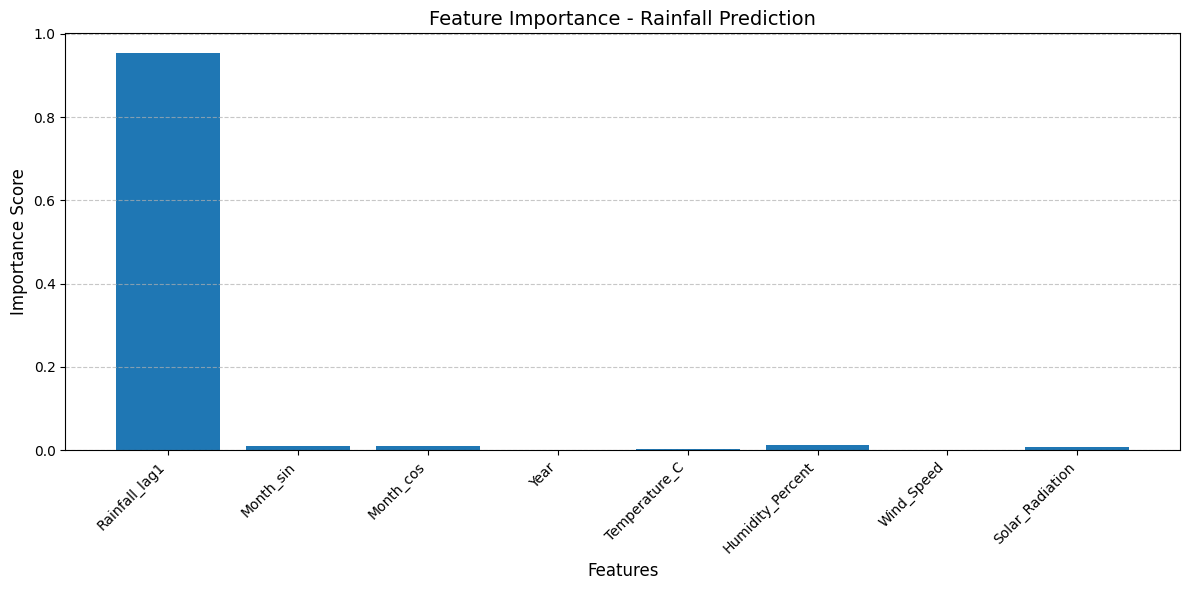

In [18]:
# -------------------------------
# 17. FEATURE IMPORTANCE
# -------------------------------


importances = best_model.feature_importances_
plt.figure(figsize=(12,6)) # Increased figure size for better readability
plt.bar(FEATURES, importances)
plt.title('Feature Importance - Rainfall Prediction', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels for better visibility
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [27]:
# -------------------------------
# 18. USER PREDICTION FUNCTION
# -------------------------------

import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

def predict_water_shortage(
    current_year, current_month, district_name_str, soil_type_name_str, crop_type_name_str
):
    print(f"\n--- Debugging Prediction for {district_name_str}, {soil_type_name_str}, {crop_type_name_str} in {current_month}/{current_year} ---")

    # 1. Encode categorical inputs and validate
    if district_name_str in label_encoders['District'].classes_:
        encoded_district = label_encoders['District'].transform([district_name_str])[0]
    else:
        raise ValueError(f"District '{district_name_str}' not found in known districts. Please choose from: {', '.join(label_encoders['District'].classes_)}")

    if soil_type_name_str in label_encoders['Soil_Type'].classes_:
        encoded_soil_type = label_encoders['Soil_Type'].transform([soil_type_name_str])[0]
    else:
        raise ValueError(f"Soil Type '{soil_type_name_str}' not found in known soil types. Please choose from: {', '.join(label_encoders['Soil_Type'].classes_)}")

    if crop_type_name_str in label_encoders['Crop_Type'].classes_:
        encoded_crop_type = label_encoders['Crop_Type'].transform([crop_type_name_str])[0]
    else:
        raise ValueError(f"Crop Type '{crop_type_name_str}' not found in known crop types. Please choose from: {', '.join(label_encoders['Crop_Type'].classes_)}")

    # 2. Look up 'last_month_rainfall' (Rainfall of previous actual month) from the dataset
    last_month_rainfall = None # Initialize
    should_prompt_other_manual_inputs = False

    prev_month_year = current_year
    prev_month = current_month - 1
    if prev_month == 0:
        prev_month = 12
        prev_month_year -= 1

    prev_month_data = df[
        (df['Year'] == prev_month_year) &
        (df['Month'] == prev_month) &
        (df['District'] == encoded_district)
    ]

    if not prev_month_data.empty:
        # Take the mean rainfall for the previous month in that district if multiple entries exist
        last_month_rainfall = prev_month_data['Rainfall'].mean()
        print(f"  - Previous month's rainfall (from dataset): {last_month_rainfall:.2f} mm")
    else:
        print(f"  - No previous month's rainfall data found for {district_name_str} in {prev_month}/{prev_month_year}.")
        choice = input("Enter '1' to manually provide last month's rainfall AND other features, or '2' to use the average rainfall for that district/month across all years: ")

        if choice == '1':
            should_prompt_other_manual_inputs = True
            try:
                last_month_rainfall = float(input(f"Please manually enter last month's rainfall (mm) for {district_name_str} in {prev_month}/{prev_month_year}: "))
                print(f"  - Previous month's rainfall (manually provided): {last_month_rainfall:.2f} mm")
            except ValueError:
                raise ValueError("Invalid input for last month's rainfall. Please enter a numerical value.")
        elif choice == '2':
            # Calculate average rainfall for that district/month across all years
            avg_rainfall_data = df[
                (df['District'] == encoded_district) &
                (df['Month'] == prev_month)
            ]['Rainfall'].mean()

            if not pd.isna(avg_rainfall_data):
                last_month_rainfall = avg_rainfall_data
                print(f"  - Previous month's rainfall (averaged from dataset): {last_month_rainfall:.2f} mm")
            else:
                raise ValueError(f"Could not calculate average rainfall for {district_name_str} in {prev_month} across all years. No data available.")
        else:
            raise ValueError("Invalid choice. Please enter '1' or '2'.")

    # 3. Look up current month's environmental features and capacities
    if should_prompt_other_manual_inputs:
        print("\n  --- Manually Input Current Month's Environmental and Capacity Data ---")
        try:
            temperature = float(input("  Temperature (C): "))
            humidity = float(input("  Humidity (%): "))
            wind = float(input("  Wind Speed: "))
            solar = float(input("  Solar Radiation: "))
            soil_capacity = float(input("  Soil Water Capacity: "))
            crop_demand = float(input("  Crop Water Demand (mm): "))
            print("  - All environmental/capacity data manually provided.")
        except ValueError:
            raise ValueError("Invalid input for environmental/capacity data. Please enter numerical values.")
    else:
        # Existing logic: Try to find a specific row matching the provided context
        current_context_data = df[
            (df['Year'] == current_year) &
            (df['Month'] == current_month) &
            (df['District'] == encoded_district) &
            (df['Soil_Type'] == encoded_soil_type) &
            (df['Crop_Type'] == encoded_crop_type)
        ]

        if not current_context_data.empty:
            # If a specific match is found, use its values
            row = current_context_data.iloc[0] # Take the first if multiple exact matches
            temperature = row['Temperature_C']
            humidity = row['Humidity_Percent']
            wind = row['Wind_Speed']
            solar = row['Solar_Radiation']
            soil_capacity = row['Soil_Water_Capacity']
            crop_demand = row['Crop_Water_Demand_mm']
            print("  - Environmental/Capacity data found for exact context (year, month, district, soil, crop).")
        else:
            print("  - No exact context found. Falling back to averages for environmental/capacity data.")
            # Fallback: Calculate averages for environmental features for the given district and month (across all years)
            # and for soil/crop capacities (across all years)
            avg_env_data = df[
                (df['District'] == encoded_district) &
                (df['Month'] == current_month)
            ].agg({
                'Temperature_C': 'mean',
                'Humidity_Percent': 'mean',
                'Wind_Speed': 'mean',
                'Solar_Radiation': 'mean'
            }).to_dict()

            temperature = avg_env_data.get('Temperature_C', df['Temperature_C'].mean()) # Default to overall mean if specific avg not found
            humidity = avg_env_data.get('Humidity_Percent', df['Humidity_Percent'].mean())
            wind = avg_env_data.get('Wind_Speed', df['Wind_Speed'].mean())
            solar = avg_env_data.get('Solar_Radiation', df['Solar_Radiation'].mean())

            # Get average Soil Water Capacity for the given soil type
            avg_soil_capacity_data = df[(df['Soil_Type'] == encoded_soil_type)]['Soil_Water_Capacity'].mean()
            soil_capacity = avg_soil_capacity_data if not pd.isna(avg_soil_capacity_data) else df['Soil_Water_Capacity'].mean()

            # Get average Crop Water Demand for the given crop type
            avg_crop_demand_data = df[(df['Crop_Type'] == encoded_crop_type)]['Crop_Water_Demand_mm'].mean()
            crop_demand = avg_crop_demand_data if not pd.isna(avg_crop_demand_data) else df['Crop_Water_Demand_mm'].mean()

            # Check if any auto-filled value is still NaN (should not happen if overall means are used as fallback)
            if pd.isna(temperature) or pd.isna(humidity) or pd.isna(wind) or pd.isna(solar) or pd.isna(soil_capacity) or pd.isna(crop_demand):
                raise ValueError("Could not automatically retrieve all necessary data for prediction even with fallbacks. Please check your inputs or the dataset coverage.")

    print(f"  - Temperature: {temperature:.2f}C, Humidity: {humidity:.2f}%, Wind: {wind:.2f}, Solar: {solar:.2f}")
    print(f"  - Soil Capacity: {soil_capacity:.2f}, Crop Demand: {crop_demand:.2f}")

    # 4. Prepare features for the model
    month_sin = np.sin(2 * np.pi * current_month / 12)
    month_cos = np.cos(2 * np.pi * current_month / 12)

    # IMPORTANT: feature order MUST match model training
    # Convert to DataFrame with feature names to avoid UserWarning
    X_user = pd.DataFrame([[
        last_month_rainfall,
        month_sin,
        month_cos,
        current_year,
        temperature,
        humidity,
        wind,
        solar
    ]], columns=FEATURES) # Use the global FEATURES list for column names

    # 5. Predict rainfall and calculate WSI and Severity
    rainfall_pred = best_model.predict(X_user)[0]
    soil_factor = soil_capacity / df['Soil_Water_Capacity'].max()
    wsi = (rainfall_pred * soil_factor) / crop_demand
    severity = classify_severity(wsi)

    print(f"  - Predicted Rainfall: {rainfall_pred:.2f} mm")
    print(f"  - Soil Retention Factor: {soil_factor:.2f}")
    print(f"  - Calculated WSI (({rainfall_pred:.2f} * {soil_factor:.2f}) / {crop_demand:.2f}): {wsi:.2f}")

    return rainfall_pred, wsi, severity


print('\n FULL PIPELINE EXECUTED SUCCESSFULLY')


 FULL PIPELINE EXECUTED SUCCESSFULLY


### 19. User Prediction Interface

Use the following cells to input specific parameters and get a prediction for rainfall, Water Shortage Index (WSI), and its severity. You'll need to know the numerical code for the district you're interested in, as well as other environmental and agricultural parameters.

In [30]:
# -------------------------------
# 20. Prediction Results
# -------------------------------

print("\nEnter the following details for a water shortage prediction:")

year = int(input("Year (e.g., 2023): "))
month = int(input("Month (1-12): "))
district_name = input("District Name (e.g., Lahore): ")
soil_type_name = input("Soil Type (e.g., Clayey): ") # Changed example to a valid one
crop_type_name = input("Crop Type (e.g., Cotton): ")

# Call the prediction function
rainfall_pred, wsi, severity = predict_water_shortage(
    year, month, district_name,
    soil_type_name, crop_type_name
)

print("\n--- Prediction Results ---")
print(f"Predicted Rainfall: {rainfall_pred:.2f} mm")
print(f"Water Shortage Index (WSI): {wsi:.2f}")
print(f"Predicted Severity: {severity}")


Enter the following details for a water shortage prediction:
Year (e.g., 2023): 2047
Month (1-12): 4
District Name (e.g., Lahore): Hafizabad
Soil Type (e.g., Clayey): Black
Crop Type (e.g., Cotton): Maize

--- Debugging Prediction for Hafizabad, Black, Maize in 4/2047 ---
  - No previous month's rainfall data found for Hafizabad in 3/2047.
Enter '1' to manually provide last month's rainfall AND other features, or '2' to use the average rainfall for that district/month across all years: 2
  - Previous month's rainfall (averaged from dataset): 73.61 mm
  - No exact context found. Falling back to averages for environmental/capacity data.
  - Temperature: 27.54C, Humidity: 40.98%, Wind: 1.75, Solar: 6.33
  - Soil Capacity: 180.00, Crop Demand: 115.30
  - Predicted Rainfall: 64.58 mm
  - Soil Retention Factor: 0.90
  - Calculated WSI ((64.58 * 0.90) / 115.30): 0.50

--- Prediction Results ---
Predicted Rainfall: 64.58 mm
Water Shortage Index (WSI): 0.50
Predicted Severity: Severe


# Error Analysis
Perform error analysis on the Gradient Boosting model's predictions on the test set and Analyze the predictions of the best model (Gradient Boosting) on the test set to identify patterns in prediction errors.

**Reasoning**:
First, I need to retrieve the best model, which is 'Gradient Boosting' from the `models` dictionary, after it has been updated with the hyperparameter tuning results. Then, I will use this `best_model` to make predictions on the `X_test` data and calculate the residuals by subtracting these predictions from the actual `y_test` values.



In [31]:
import matplotlib.pyplot as plt

# 1. Re-assign best_model from the models dictionary (updated after tuning)
best_model = models['Gradient Boosting']

# Make predictions on the test set
gb_predictions = best_model.predict(X_test)

# 2. Calculate residuals
gb_residuals = y_test - gb_predictions

print('Predictions and residuals calculated successfully.')

Predictions and residuals calculated successfully.


**Reasoning**:
To visually assess the model's performance and identify any systematic biases, I will create a scatter plot comparing the actual rainfall values (`y_test`) against the predicted rainfall values (`gb_predictions`). A diagonal line representing perfect predictions will serve as a reference.



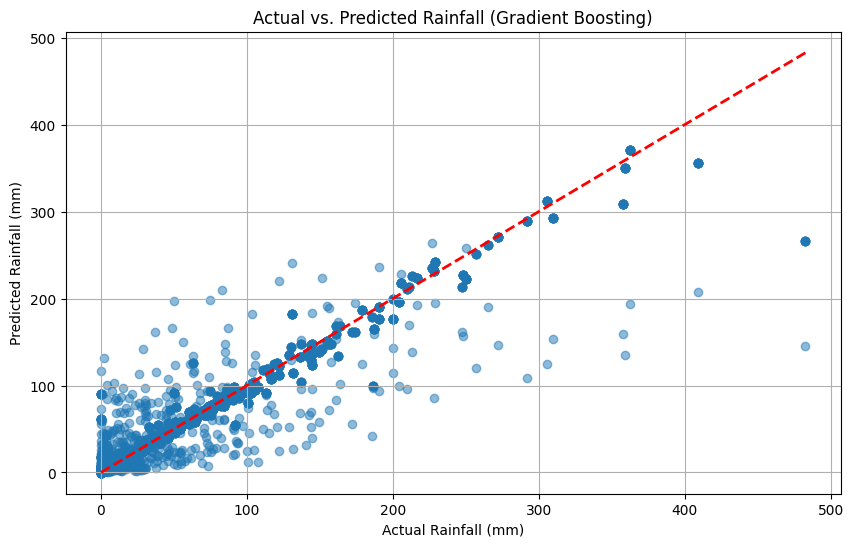

Scatter plot of actual vs. predicted rainfall generated.


In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gb_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')
plt.title('Actual vs. Predicted Rainfall (Gradient Boosting)')
plt.grid(True)
plt.show()

print('Scatter plot of actual vs. predicted rainfall generated.')

**Reasoning**:
To understand the nature of the prediction errors, I will create a histogram of the residuals (`gb_residuals`). This will show the distribution of errors and help identify if they are centered around zero, normally distributed, or skewed in any way.



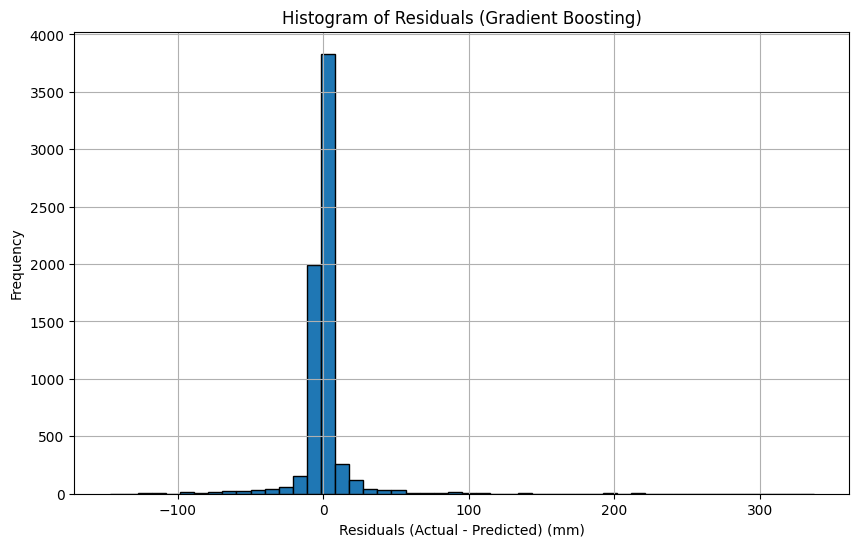

Histogram of residuals generated.


In [23]:
plt.figure(figsize=(10, 6))
plt.hist(gb_residuals, bins=50, edgecolor='black')
plt.xlabel('Residuals (Actual - Predicted) (mm)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (Gradient Boosting)')
plt.grid(True)
plt.show()

print('Histogram of residuals generated.')

**Reasoning**:
To check for heteroscedasticity or other patterns in the errors, I will create a scatter plot of the predicted rainfall values against the residuals. This helps visualize if the model's errors are consistent across all prediction magnitudes or if they vary systematically.



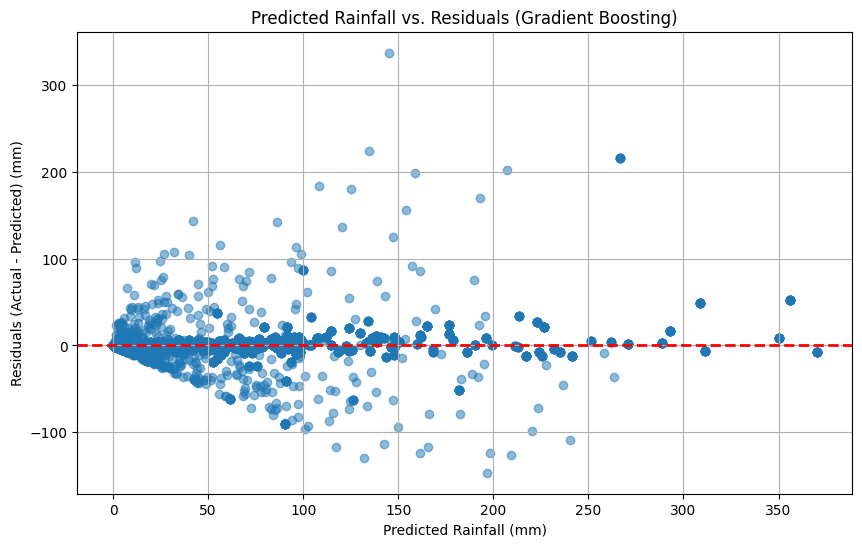

Scatter plot of predicted rainfall vs. residuals generated.


In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(gb_predictions, gb_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Zero-error line
plt.xlabel('Predicted Rainfall (mm)')
plt.ylabel('Residuals (Actual - Predicted) (mm)')
plt.title('Predicted Rainfall vs. Residuals (Gradient Boosting)')
plt.grid(True)
plt.show()

print('Scatter plot of predicted rainfall vs. residuals generated.')

**Reasoning**:
To identify the most significant over- and under-predictions, I will combine the actual values, predictions, and residuals into a single DataFrame and then sort it to extract the top 5 positive and negative residuals.



In [25]:
results_df = pd.DataFrame({
    'Actual_Rainfall': y_test,
    'Predicted_Rainfall': gb_predictions,
    'Residuals': gb_residuals
})

print('\n--- Top 5 Largest Positive Residuals (Under-predictions) ---')
print(results_df.nlargest(5, 'Residuals'))

print('\n--- Top 5 Largest Negative Residuals (Over-predictions) ---')
print(results_df.nsmallest(5, 'Residuals'))



--- Top 5 Largest Positive Residuals (Under-predictions) ---
       Actual_Rainfall  Predicted_Rainfall   Residuals
30536            482.6          145.287916  337.312084
32968            358.7          134.566285  224.133715
30537            482.6          266.586873  216.013127
30538            482.6          266.586873  216.013127
30539            482.6          266.586873  216.013127

--- Top 5 Largest Negative Residuals (Over-predictions) ---
       Actual_Rainfall  Predicted_Rainfall   Residuals
32046             50.2          196.908585 -146.708585
32851              2.0          131.882396 -129.882396
26974             82.9          209.407750 -126.507750
32202             37.3          161.689739 -124.389739
30504             74.9          198.418581 -123.518581


### Additional Diagnostic Plots
To further understand the model's behavior, we can look at:
1. **Q-Q Plot**: To check if the residuals follow a normal distribution.
2. **Residuals vs. Month**: To see if there are seasonal patterns in the errors.
3. **Actual vs. Predicted (Time Series)**: To visualize how well the model tracks changes over a subset of the data.

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(10, 6))
stats.probplot(gb_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals (Gradient Boosting)')
plt.grid(True)
plt.show()

print('Q-Q plot generated.')

In [ ]:
# Recover Month from the original dataframe using the index of X_test
# We use the index because train_test_split was done with shuffle=False, preserving order/indices
test_months = df.loc[X_test.index, 'Month']

plt.figure(figsize=(12, 6))
plt.scatter(test_months, gb_residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Month')
plt.ylabel('Residuals (Actual - Predicted) (mm)')
plt.title('Residuals by Month (Checking for Seasonal Bias)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

print('Residuals vs. Month plot generated.')

In [ ]:
# Plot a subset of the test data to see how the model tracks individual events
subset_size = 100
plt.figure(figsize=(15, 6))
plt.plot(range(subset_size), y_test.iloc[:subset_size].values, label='Actual', marker='o', markersize=4)
plt.plot(range(subset_size), gb_predictions[:subset_size], label='Predicted', marker='x', markersize=4, linestyle='--')
plt.title(f'Actual vs. Predicted Rainfall (First {subset_size} Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

print('Time series comparison plot generated.')

## Create Comparison Table

### Subtask:
Generate a clear comparison table (e.g., a pandas DataFrame) of the evaluation metrics (MAE, RMSE, R2) for all the trained machine learning models, including the baseline model and the hyperparameter-tuned Gradient Boosting model.


**Reasoning**:
I need to consolidate the evaluation metrics from the baseline model, all initial ML models, and the hyperparameter-tuned Gradient Boosting model into a single comparison table. I will initialize a dictionary, populate it with existing metrics, calculate metrics for the tuned model, and then convert this dictionary into a pandas DataFrame as instructed.



In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize an empty dictionary to store all model results
all_model_results = {}

# 2. Add the baseline model's MAE, RMSE, and R2 scores

all_model_results['Baseline Model'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

# 3. Iterate through the 'results' dictionary (initial ML models) and add them
# 'results' contains Linear Regression, SVR, Decision Tree, Random Forest, and initial Gradient Boosting
for name, metrics in results.items():
    all_model_results[name] = metrics

# 4. Calculate and add metrics for the hyperparameter-tuned Gradient Boosting model
# The tuned model is stored in grid_search.best_estimator_
tuned_gb_model = grid_search.best_estimator_
tuned_gb_preds = tuned_gb_model.predict(X_test)

tuned_gb_mae = mean_absolute_error(y_test, tuned_gb_preds)
tuned_gb_rmse = np.sqrt(mean_squared_error(y_test, tuned_gb_preds))
tuned_gb_r2 = r2_score(y_test, tuned_gb_preds)

all_model_results['Gradient Boosting (Tuned)'] = {
    'MAE': tuned_gb_mae,
    'RMSE': tuned_gb_rmse,
    'R2': tuned_gb_r2
}

# 5. Convert the dictionary of results into a pandas DataFrame
comparison_df = pd.DataFrame.from_dict(all_model_results, orient='index')

# 6. Print the resulting comparison DataFrame
print('Model Performance Comparison Table:')
print(comparison_df.round(4))


Model Performance Comparison Table:
                               MAE     RMSE      R2
Baseline Model              3.5540  20.8775  0.8963
Linear Regression           9.0188  19.6098  0.9085
SVR                        19.6719  36.1490  0.6892
Decision Tree              15.8081  35.0620  0.7076
Random Forest              10.1759  20.7159  0.8979
Gradient Boosting           6.5210  17.7900  0.9247
Gradient Boosting (Tuned)   6.2032  17.1230  0.9303
